# K Means Clustering

## Learning objective

This notebook covers **K Means**, the most widely used **unsupervised**
clustering algorithm. Unlike the supervised models in this repository, K Means
never sees any labels; it groups points purely from their geometry. You should
finish able to:

- explain what unsupervised learning and clustering are,
- state the K Means objective (the within-cluster sum of squared distances),
- describe the iterative assign/update algorithm and why it converges,
- implement a `KMeansScratch` class from scratch with `fit`, `predict`, and an
  inertia calculation, and
- discuss sensitivity to initialization, the choice of $k$, feature scaling,
  non-spherical clusters, and local minima.

## The mathematical idea

**Unsupervised learning** looks for structure in a feature matrix $X$ without
any target labels $y$. **Clustering** is the task of partitioning the rows of
$X$ into groups so that points in the same group are similar and points in
different groups are dissimilar.

K Means makes this precise. Given $k$ clusters, it represents each cluster by a
**centroid** $\mu_c$ and assigns every point to its nearest centroid. It seeks
the assignment and centroids that minimize the **within-cluster sum of squared
distances**, also called the **inertia**:

$$
J = \sum_{c=1}^{k} \sum_{x_i \in C_c} \lVert x_i - \mu_c \rVert^2 ,
$$

where $C_c$ is the set of points assigned to cluster $c$. Minimizing $J$ exactly
is NP-hard, so K Means uses a simple iterative scheme (Lloyd's algorithm) that
alternates two steps:

1. **Initialize** the $k$ centroids (here, by picking $k$ random data points).
2. **Assign** each point to the nearest centroid.
3. **Update** each centroid to the mean of the points currently assigned to it.
4. **Repeat** steps 2-3 until convergence (the centroids stop moving) or a
   maximum number of iterations is reached.

Each step can only lower or leave unchanged the objective $J$, so the algorithm
is guaranteed to converge — though only to a **local** minimum that depends on
the starting centroids.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Fixed seed so the synthetic data and the runs below are reproducible.
SEED = 42
rng = np.random.default_rng(SEED)

## A reproducible dataset

We generate a small two-dimensional synthetic dataset with **three visible
clusters**, each a Gaussian blob around a different center. Because clustering
is unsupervised, the algorithm only ever receives the feature matrix `X`; the
`true_cluster` labels are kept aside purely so we can talk about the data and
are never passed to the model.

In [2]:
n_per_cluster = 80
centers = np.array([[-3.0, 0.0], [3.0, 0.0], [0.0, 4.0]])

blobs = [rng.normal(loc=c, scale=0.8, size=(n_per_cluster, 2)) for c in centers]
X = np.vstack(blobs)
true_cluster = np.repeat(np.arange(len(centers)), n_per_cluster)

# Shuffle so the rows are not grouped by cluster.
order = rng.permutation(X.shape[0])
X, true_cluster = X[order], true_cluster[order]

print('Feature matrix shape:', X.shape)
print('Number of true clusters:', len(centers))

Feature matrix shape: (240, 2)
Number of true clusters: 3


## The raw, unlabeled data

This is what K Means actually starts from: a cloud of points with no labels. By
eye there appear to be three groups, but the algorithm has to discover that
structure on its own.

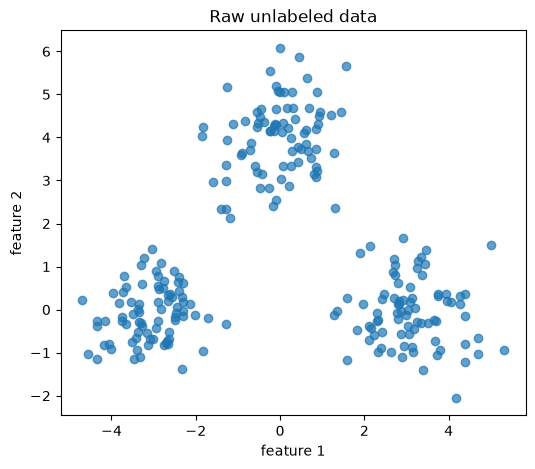

In [3]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(X[:, 0], X[:, 1], alpha=0.7)
ax.set_xlabel('feature 1')
ax.set_ylabel('feature 2')
ax.set_title('Raw unlabeled data')
plt.show()

## K Means from scratch

The `KMeansScratch` class implements Lloyd's algorithm directly with NumPy:

- **`_init_centroids`** picks `n_clusters` distinct data points as the starting
  centroids, using a fixed `random_state` so a given run is reproducible.
- **`_distances`** returns the matrix of Euclidean distances from every point to
  every centroid.
- **`fit`** alternates the assign and update steps, recording the inertia at
  each iteration in `inertia_history_`, and stops when the total centroid
  movement falls below `tol` or `max_iter` is reached.
- **`predict`** assigns new points to the nearest learned centroid.
- **`_inertia`** computes the within-cluster sum of squared distances for a
  given assignment.

Convergence is judged by the **centroid movement**: once the centroids barely
shift between iterations, the partition has stabilized.

In [4]:
class KMeansScratch:
    """A from-scratch K Means clustering model (Lloyd's algorithm)."""

    def __init__(self, n_clusters=3, max_iter=100, tol=1e-4, random_state=0):
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.tol = tol
        self.random_state = random_state

    def _init_centroids(self, X):
        # Choose n_clusters distinct points as the initial centroids.
        rng = np.random.default_rng(self.random_state)
        idx = rng.choice(X.shape[0], size=self.n_clusters, replace=False)
        return X[idx].copy()

    @staticmethod
    def _distances(X, centroids):
        # (n_samples, n_clusters) matrix of Euclidean distances.
        return np.linalg.norm(X[:, None, :] - centroids[None, :, :], axis=2)

    def _inertia(self, X, labels):
        # Within-cluster sum of squared distances to the assigned centroid.
        total = 0.0
        for k in range(self.n_clusters):
            pts = X[labels == k]
            if len(pts):
                total += float(((pts - self.centroids_[k]) ** 2).sum())
        return total

    def fit(self, X):
        X = np.asarray(X, dtype=float)
        centroids = self._init_centroids(X)
        self.inertia_history_ = []

        for i in range(self.max_iter):
            # Assign step: nearest centroid for each point.
            distances = self._distances(X, centroids)
            labels = distances.argmin(axis=1)

            # Record the inertia for this assignment.
            nearest = distances[np.arange(X.shape[0]), labels]
            self.inertia_history_.append(float((nearest ** 2).sum()))

            # Update step: move each centroid to the mean of its points.
            new_centroids = np.array([
                X[labels == k].mean(axis=0) if np.any(labels == k)
                else centroids[k]
                for k in range(self.n_clusters)
            ])

            # Convergence test: total centroid movement.
            shift = np.linalg.norm(new_centroids - centroids)
            centroids = new_centroids
            if shift <= self.tol:
                break

        self.centroids_ = centroids
        self.labels_ = self.predict(X)
        self.inertia_ = self._inertia(X, self.labels_)
        self.n_iter_ = i + 1
        return self

    def predict(self, X):
        X = np.asarray(X, dtype=float)
        return self._distances(X, self.centroids_).argmin(axis=1)

## Fit the model

We run K Means with $k = 3$ to match the three blobs we generated. The model is
given only `X`. After fitting we report how many iterations it took, the final
inertia, and the size of each discovered cluster — all computed by the code
rather than written in by hand.

In [5]:
model = KMeansScratch(n_clusters=3, random_state=SEED).fit(X)

counts = {int(k): int((model.labels_ == k).sum())
          for k in range(model.n_clusters)}
print('Iterations to converge:', model.n_iter_)
print('Final inertia:', round(model.inertia_, 4))
print('Cluster sizes:', counts)

Iterations to converge: 10
Final inertia: 278.6124
Cluster sizes: {0: 80, 1: 79, 2: 81}


## The discovered clusters

We color each point by the cluster K Means assigned to it and mark the learned
centroids with large `X` markers. All colors come from matplotlib's default
color cycle: we draw one scatter call per cluster, and the centroid markers take
the next default color.

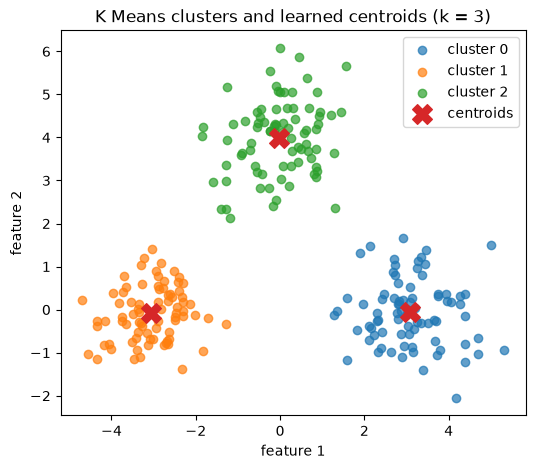

In [6]:
fig, ax = plt.subplots(figsize=(6, 5))
for k in range(model.n_clusters):
    pts = X[model.labels_ == k]
    ax.scatter(pts[:, 0], pts[:, 1], alpha=0.7, label=f'cluster {k}')
ax.scatter(model.centroids_[:, 0], model.centroids_[:, 1],
           marker='X', s=200, label='centroids')
ax.set_xlabel('feature 1')
ax.set_ylabel('feature 2')
ax.set_title('K Means clusters and learned centroids (k = 3)')
ax.legend()
plt.show()

## Inertia over iterations

The objective $J$ can only decrease as the algorithm runs. Plotting the recorded
inertia against the iteration number shows it dropping quickly and then leveling
off as the centroids settle — a visual confirmation that the algorithm is
monotonically improving the assignment.

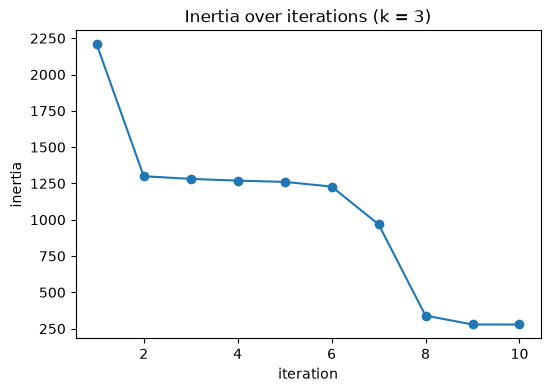

In [7]:
history = model.inertia_history_

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(range(1, len(history) + 1), history, marker='o')
ax.set_xlabel('iteration')
ax.set_ylabel('inertia')
ax.set_title('Inertia over iterations (k = 3)')
plt.show()

## How many clusters? An elbow-style check

In practice we rarely know the true number of clusters. One common heuristic is
to fit K Means for a range of $k$ values and plot the final inertia against $k$.
Inertia always falls as $k$ grows (more centroids fit the data more tightly),
but the rate of improvement often slows sharply at the "right" $k$, producing an
**elbow** in the curve.

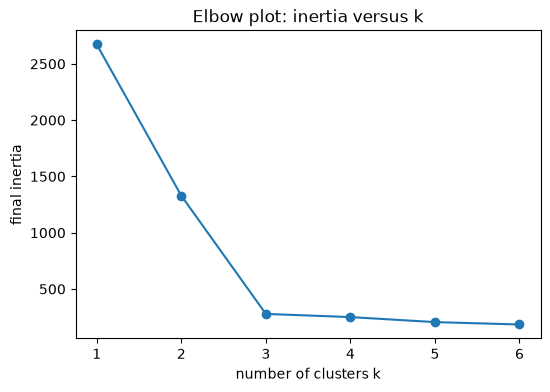

In [8]:
k_values = range(1, 7)
inertias = [KMeansScratch(n_clusters=k, random_state=SEED).fit(X).inertia_
            for k in k_values]

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(list(k_values), inertias, marker='o')
ax.set_xlabel('number of clusters k')
ax.set_ylabel('final inertia')
ax.set_title('Elbow plot: inertia versus k')
plt.show()

## Interpretation

With $k = 3$ the algorithm recovers the three blobs we built, placing a centroid
near the middle of each one. The inertia curve confirms that the objective
decreases monotonically and stabilizes after only a few iterations. In the
elbow plot the inertia drops steeply from $k = 1$ to $k = 3$ and then flattens,
so the bend near $k = 3$ agrees with the structure we can see by eye.

### Limitations and next steps

- **Sensitivity to initialization.** Lloyd's algorithm only finds a *local*
  minimum, and different starting centroids can lead to different partitions. In
  practice K Means is run several times from different seeds and the result with
  the lowest inertia is kept; smarter seeding such as **k-means++** spreads the
  initial centroids out to make a good outcome more likely.
- **Choosing $k$.** The number of clusters is a hyperparameter the algorithm
  cannot choose for itself. The elbow heuristic is only a guide; other tools
  (for example silhouette scores) and domain knowledge are often needed.
- **Feature scaling.** Inertia is built from Euclidean distances, so a feature
  measured on a large numeric scale will dominate the clustering. Features
  should usually be standardized before running K Means.
- **Non-spherical clusters.** Assigning points to the nearest centroid carves
  the space into convex, roughly spherical regions. Clusters that are elongated,
  curved, or of very different densities are modeled poorly, and approaches such
  as Gaussian mixtures or density-based clustering can do better.
- **Local minima.** Because the objective is non-convex, even a perfect choice
  of $k$ does not guarantee the global optimum from any single run.

Natural next steps are to add k-means++ initialization, run multiple restarts
and keep the best inertia, standardize the features first, and compare the
elbow heuristic against a silhouette analysis.